# 2025 CITS4012 Project

# 1.Dataset Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [ ]:
import torch
print(torch.__version__)

2.8.0+cu126


In [ ]:
!pip install torchtext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.3 MB/s eta 0:00:00


In [ ]:
import os
import re
import json
import math
import time
import csv
import urllib.request
import zipfile
import numpy as np
from typing import List, Dict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import spacy
from sklearn.metrics import accuracy_score

In [ ]:
import os
import re
import json
from typing import List, Dict
import spacy

def clean_text(text: str) -> str:
    """
    Clean noisy text: remove special symbols, escape sequences, and junk markers.
    """
    if not isinstance(text, str):
        return ""

    # 1. Remove HTML-like tags and DOC markers
    text = re.sub(r"<\/?DOC[^>]*>", " ", text)
    text = re.sub(r"<\/?[^>]+>", " ", text)

    # 2. Remove long sequences of separators (=, -, _, *, #, $, ~, etc.)
    text = re.sub(r"[=*_~#\-]{3,}", " ", text)

    # 3. Remove special tokens such as X1014316970-00284-62165
    text = re.sub(r"X\d{5,}-\d{5,}-\d{5,}", " ", text)

    # 4. Remove escape characters
    text = text.replace("\\n", " ").replace("\\t", " ").replace("\\/", "/").replace("\\", " ")

    # 5. Remove miscellaneous special symbols ($, @, #, %, &, etc.)
    text = re.sub(r"[$@#%&*^<>|`~]+", " ", text)

    # 6. Remove extra spaces and repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # 7. Remove invalid UTF-8 characters
    text = text.encode("utf-8", "ignore").decode("utf-8", "ignore")

    return text

def load_nli_json(path: str) -> List[Dict]:
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)
    keys = list(raw.keys())
    lens = None
    for k in ["premise", "hypothesis", "label"]:
        if k in raw:
            lens = len(raw[k])
            break
    if lens is None:
        raise ValueError("JSON format not recognized: expected keys 'premise','hypothesis','label'.")
    data = []
    for i in range(lens):
        si = str(i)
        p = clean_text(raw["premise"].get(si, ""))
        h = clean_text(raw["hypothesis"].get(si, ""))
        lab = raw["label"].get(si, "").strip().lower()
        if lab not in ("entails", "neutral"):
            continue
        data.append({"premise": p, "hypothesis": h, "label": lab})
    return data

# ---------------------------
# Data loading with configurable paths and file checks
# ---------------------------
def load_datasets(data_dir="/content"):
    print(f"Checking dataset files in {data_dir}...")
    train_path = os.path.join(data_dir, "train.json")
    val_path = os.path.join(data_dir, "validation.json")
    test_path = os.path.join(data_dir, "test.json")

    # Check if files exist
    if not os.path.exists(train_path):
        raise FileNotFoundError(
            f"Training file {train_path} not found. Please upload 'train.json' to {data_dir} "
            "using the Colab file upload or mount Google Drive with the file."
        )
    if not os.path.exists(val_path):
        raise FileNotFoundError(
            f"Validation file {val_path} not found. Please upload 'validation.json' to {data_dir} "
            "using the Colab file upload or mount Google Drive with the file."
        )
    if not os.path.exists(test_path):
        raise FileNotFoundError(
            f"Test file {test_path} not found. Please upload 'test.json' to {data_dir} "
            "using the Colab file upload or mount Google Drive with the file."
        )

    print("Loading data...")
    train_data = load_nli_json(train_path)
    val_data = load_nli_json(val_path)
    test_data = load_nli_json(test_path)
    return train_data, val_data, test_data

# Main execution
if __name__ == "__main__":
    data_dir = "/content"  # Change this to your desired directory, e.g., "/content/drive/MyDrive/data"
    train_data, val_data, test_data = load_datasets(data_dir)
    print(train_data[:5],val_data[:5],test_data[:5])

    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "tagger"])
    vocab_set = set()
    for s in train_data:
        vocab_set.update([t.text.lower() for t in nlp(s["premise"])])
        vocab_set.update([t.text.lower() for t in nlp(s["hypothesis"])])
    vocab = ["<pad>", "<unk>"] + sorted(list(vocab_set))
    word_to_idx = {w: i for i, w in enumerate(vocab)}
    print(f"Vocab size: {len(vocab)}")
    print(f"Vocabulary size: {len(vocab)} words")
    print(f"Example word to index mapping: {list(word_to_idx.items())[:10]}")

Checking dataset files in /content...
Loading data...
[{'premise': 'Pluto rotates once on its axis every 6.39 Earth days;', 'hypothesis': 'Earth rotates on its axis once times in one day.', 'label': 'neutral'}, {'premise': 'Glenn Once per day, the earth rotates about its axis.', 'hypothesis': 'Earth rotates on its axis once times in one day.', 'label': 'entails'}, {'premise': 'geysers - periodic gush of hot water at the surface of the Earth.', 'hypothesis': 'The surface of the sun is much hotter than almost anything on earth.', 'label': 'neutral'}, {'premise': 'Facts: Liquid water droplets can be changed into invisible water vapor through a process called evaporation .', 'hypothesis': 'Evaporation is responsible for changing liquid water into water vapor.', 'label': 'entails'}, {'premise': 'By comparison, the earth rotates on its axis once per day and revolves around the sun once per year.', 'hypothesis': 'Earth rotates on its axis once times in one day.', 'label': 'entails'}] [{'premi

/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


Vocab size: 21115
Vocabulary size: 21115 words
Example word to index mapping: [('<pad>', 0), ('<unk>', 1), ('!', 2), ('"', 3), ("'", 4), ("''", 5), ("'d", 6), ("'ll", 7), ("'m", 8), ("'re", 9)]


In [ ]:
# ---------------------------
# Dataset Definition
# ---------------------------

class NLIDataset(Dataset):
    def __init__(self, data, tokenizer, word_to_idx, max_len=50):
        self.data = data
        self.tokenizer = tokenizer
        self.word_to_idx = word_to_idx
        self.max_len = max_len
        # Preprocess and cache
        self.preprocessed = []
        for item in data:
            premise_ids = self.encode_sentence(item["premise"])
            hypothesis_ids = self.encode_sentence(item["hypothesis"])
            label = 1 if item["label"] == "entails" else 0
            self.preprocessed.append((premise_ids, hypothesis_ids, torch.tensor(label, dtype=torch.float32)))

    def encode_sentence(self, sentence):
        sentence = clean_text(sentence)
        tokens = [t.text.lower() for t in self.tokenizer(sentence)]
        ids = [self.word_to_idx.get(tok, self.word_to_idx["<unk>"]) for tok in tokens]
        if len(ids) < self.max_len:
            ids += [self.word_to_idx["<pad>"]] * (self.max_len - len(ids))
        else:
            ids = ids[:self.max_len]
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        premise = self.encode_sentence(item["premise"])
        hypothesis = self.encode_sentence(item["hypothesis"])
        label = 1 if item["label"] == "entails" else 0
        return premise, hypothesis, torch.tensor(label, dtype=torch.float32)


In [ ]:
# ---------------------------
# Load GloVe (optional)
# ---------------------------
def load_glove_embeddings(glove_path="/content/.cache"):
    glove_file = os.path.join(glove_path, "glove.6B.100d.txt")
    glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
    zip_path = os.path.join(glove_path, "glove.6B.zip")

    # Check if glove.6B.100d.txt exists
    if not os.path.exists(glove_file):
        print(f"[INFO] GloVe file {glove_file} not found. Attempting to download...")
        try:
            # Ensure cache directory exists
            os.makedirs(glove_path, exist_ok=True)
            # Download glove.6B.zip
            print(f"[INFO] Downloading {glove_url} to {zip_path}")
            urllib.request.urlretrieve(glove_url, zip_path)
            # Unzip and extract glove.6B.100d.txt
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extract("glove.6B.100d.txt", glove_path)
            print(f"[INFO] Extracted glove.6B.100d.txt to {glove_path}")
            # Clean up zip file
            os.remove(zip_path)
        except Exception as e:
            raise RuntimeError(
                f"Failed to download or extract GloVe: {str(e)}. Please manually upload "
                f"'glove.6B.100d.txt' to {glove_path} and try again."
            )

    # Parse GloVe file
    embeddings = {}
    try:
        with open(glove_file, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.rstrip().split(" ")
                word = parts[0]
                vector = np.array(parts[1:], dtype=np.float32)
                embeddings[word] = torch.from_numpy(vector)
        print(f"[INFO] Loaded GloVe embeddings from {glove_file} with {len(embeddings)} words.")
        return embeddings
    except Exception as e:
        raise RuntimeError(
            f"Failed to parse GloVe file {glove_file}: {str(e)}. Ensure the file is valid and not corrupted."
        )

# 2.Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## Model A: Model (multiple attention variants)

In [ ]:

# ---------------------------
# Model (multiple attention variants)
# ---------------------------
class AttentionBiLSTM(nn.Module):
    def __init__(self, embedding_matrix: torch.Tensor, hidden_dim=128, attention_type="self", dropout_rate=0.3):
        """
        attention_type: "self", "dot", "general", "additive"
        dropout_rate: dropout probability applied after BiLSTM
        """
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.bilstm = nn.LSTM(embed_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.hidden_dim = hidden_dim
        self.att_type = attention_type

        self.att_self = nn.Linear(hidden_dim * 2, 1)
        if attention_type == "general":
            self.W_general = nn.Linear(hidden_dim * 2, hidden_dim * 2, bias=False)
        if attention_type == "additive":
            self.W_a = nn.Linear(hidden_dim * 2, hidden_dim)
            self.U_b = nn.Linear(hidden_dim * 2, hidden_dim, bias=False)
            self.v = nn.Linear(hidden_dim, 1, bias=False)

        self.fc = nn.Linear(hidden_dim * 4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, premise, hypothesis):
        p_emb = self.embedding(premise)
        h_emb = self.embedding(hypothesis)
        p_out, _ = self.bilstm(p_emb)
        h_out, _ = self.bilstm(h_emb)
        p_out = self.dropout(p_out)
        h_out = self.dropout(h_out)

        if self.att_type == "self":
            p_scores = torch.softmax(self.att_self(p_out), dim=1)
            h_scores = torch.softmax(self.att_self(h_out), dim=1)
            p_vec = torch.sum(p_scores * p_out, dim=1)
            h_vec = torch.sum(h_scores * h_out, dim=1)
        elif self.att_type == "dot":
            E = torch.bmm(p_out, h_out.transpose(1, 2))
            alpha = torch.softmax(E, dim=2)
            a_p = torch.bmm(alpha, h_out)
            p_vec = a_p.mean(dim=1)
            beta = torch.softmax(E.transpose(1, 2), dim=2)
            b_h = torch.bmm(beta, p_out)
            h_vec = b_h.mean(dim=1)
        elif self.att_type == "general":
            h_trans = self.W_general(h_out)
            E = torch.bmm(p_out, h_trans.transpose(1, 2))
            alpha = torch.softmax(E, dim=2)
            a_p = torch.bmm(alpha, h_trans)
            p_vec = a_p.mean(dim=1)
            beta = torch.softmax(E.transpose(1,2), dim=2)
            b_h = torch.bmm(beta, p_out)
            h_vec = b_h.mean(dim=1)
        elif self.att_type == "additive":
            B, m, d = p_out.size()
            n = h_out.size(1)
            Wa_ai = self.W_a(p_out)
            Ub_bj = self.U_b(h_out)
            Wa_ai_exp = Wa_ai.unsqueeze(2).expand(-1, -1, n, -1)
            Ub_bj_exp = Ub_bj.unsqueeze(1).expand(-1, m, -1, -1)
            e = torch.tanh(Wa_ai_exp + Ub_bj_exp)
            e = self.v(e).squeeze(-1)
            alpha = torch.softmax(e, dim=2)
            a_p = torch.bmm(alpha, h_out)
            p_vec = a_p.mean(dim=1)
            beta = torch.softmax(e.transpose(1,2), dim=2)
            b_h = torch.bmm(beta, p_out)
            h_vec = b_h.mean(dim=1)
        else:
            raise ValueError(f"Unknown att_type: {self.att_type}")

        combined = torch.cat([p_vec, h_vec], dim=1)
        logits = self.fc(combined)
        return self.sigmoid(logits).squeeze()

In [ ]:
# ---------------------------
# Training / Evaluation helpers
# ---------------------------
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for premise, hypothesis, label in loader:
        premise, hypothesis, label = premise.to(device), hypothesis.to(device), label.to(device)
        optimizer.zero_grad()
        outputs = model(premise, hypothesis)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / max(1, len(loader))

def eval_model(model, loader, device):
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for premise, hypothesis, label in loader:
            premise, hypothesis, label = premise.to(device), hypothesis.to(device), label.to(device)
            outputs = model(premise, hypothesis)
            preds += (outputs > 0.5).int().cpu().tolist()
            labs += label.int().cpu().tolist()
    return accuracy_score(labs, preds)

In [ ]:
# ---------------------------
# Experiment runner
# ---------------------------
def run_experiments(
    glove_path="glove.6B.100d.txt",
    hidden_sizes=[128],
    attention_types=["self", "dot", "general"],
    batch_sizes=[32],
    learning_rates=[1e-4, 1e-3, 2e-3],
    dropout_rates=[0.2],
    epochs=3,
    max_len=50,
    patience=2,
    out_csv="experiment_results.csv"
):

    glove = load_glove_embeddings(glove_path)
    embedding_dim = 100
    embedding_matrix = torch.zeros((len(vocab), embedding_dim))
    for i, word in enumerate(vocab):
        if word in glove:
            embedding_matrix[i] = glove[word]
        else:
            embedding_matrix[i] = torch.randn(embedding_dim) * 0.1

    train_dataset = NLIDataset(train_data, nlp, word_to_idx, max_len=max_len)
    val_dataset = NLIDataset(val_data, nlp, word_to_idx, max_len=max_len) if val_data else None
    test_dataset = NLIDataset(test_data, nlp, word_to_idx, max_len=max_len) if test_data else None

    # Print first 5 samples from each dataset
    print("\n=== Dataset Samples ===")
    print("Train Dataset (first 5 samples):")
    for i in range(min(5, len(train_dataset))):
        premise_ids, hypothesis_ids, label = train_dataset[i]
        print(f"Sample {i}: Premise={premise_ids.tolist()}, Hypothesis={hypothesis_ids.tolist()}, Label={label.item()}")
    if val_dataset:
        print("Validation Dataset (first 5 samples):")
        for i in range(min(5, len(val_dataset))):
            premise_ids, hypothesis_ids, label = val_dataset[i]
            print(f"Sample {i}: Premise={premise_ids.tolist()}, Hypothesis={hypothesis_ids.tolist()}, Label={label.item()}")
    if test_dataset:
        print("Test Dataset (first 5 samples):")
        for i in range(min(5, len(test_dataset))):
            premise_ids, hypothesis_ids, label = test_dataset[i]
            print(f"Sample {i}: Premise={premise_ids.tolist()}, Hypothesis={hypothesis_ids.tolist()}, Label={label.item()}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"GPU available: {torch.cuda.is_available()}, Device: {device}, Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

    with open(out_csv, "w", newline="", encoding="utf-8") as csvf:
        writer = csv.writer(csvf)
        writer.writerow(["timestamp","att_type","hidden_dim","batch_size","learning_rate","dropout_rate","epochs","val_acc","test_acc","train_loss","runtime_sec"])

    for att in attention_types:
      for lr in learning_rates:
          print(f"\n=== Experiment: att={att}, hidden=128, batch_size=32, lr={lr}, dropout=0.2 ===")
          train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2,pin_memory=True)
          val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2,pin_memory=True) if val_dataset else None
          test_loader = DataLoader(test_dataset, batch_size=32, num_workers=2,pin_memory=True) if test_dataset else None
          model = AttentionBiLSTM(embedding_matrix, hidden_dim=128, attention_type=att, dropout_rate=0.2).to(device)
          criterion = nn.BCELoss()
          optimizer = optim.Adam(model.parameters(), lr=lr)
          start = time.time()
          train_losses = []
          best_val_acc = 0
          no_improve = 0
          for ep in range(epochs):
              loss = train_epoch(model, train_loader, optimizer, criterion, device)
              train_losses.append(loss)
              print(f" Ep {ep+1}/{epochs} loss {loss:.4f}")
              if val_loader:
                  val_acc = eval_model(model, val_loader, device)
                  print(f" Val acc: {val_acc:.4f}")
                  if val_acc > best_val_acc:
                      best_val_acc = val_acc
                      no_improve = 0
                  else:
                      no_improve += 1
                  if no_improve >= patience:
                      print(f"Early stopping at epoch {ep+1}")
                      break
          runtime = time.time() - start
          val_acc = eval_model(model, val_loader, device) if val_loader else None
          test_acc = eval_model(model, test_loader, device) if test_loader else None
          print(f"Result -> val_acc: {val_acc}, test_acc: {test_acc}, runtime: {runtime:.1f}s")

          with open(out_csv, "a", newline="", encoding="utf-8") as csvf:
              writer = csv.writer(csvf)
              writer.writerow([time.strftime("%Y-%m-%d %H:%M:%S"), att, 128, 32, lr, 0.2, ep+1, val_acc, test_acc, sum(train_losses)/len(train_losses), round(runtime,1)])

    print(f"All experiments done. Results saved to {out_csv}")


## Model B: Encoder-Decoder Model with Cross-Attention

### Description

This is a rather typical encoder-decoder model with cross attention.Its design is similar, if not identical, to what is introduced during lecture 7. There are, of course, some major differences which distinct this from that of lecture 7. But I won't elaborate on those details here, since they are supposed to be discussed in the report.

### Reminder

Please note that this section reused many components built in the previous section. So make sure that you have run the code cells from the first till the one that "Load GloVe".

In [ ]:
# [B-1] Model B Configuration
MODEL_B_CONFIG = {
    'hidden_dim': 128,
    'dropout_rate': 0.2,
    'pooling_types': ['mean', 'max', 'last', 'attention'],  # Ablation variants
    'learning_rate': 1e-3,
    'batch_size': 32,
    'epochs': 3,
    'patience': 2,
    'max_len': 50
}

print("Model B Configuration:")
for key, value in MODEL_B_CONFIG.items():
    print(f"  {key}: {value}")

Model B Configuration:
  hidden_dim: 128
  dropout_rate: 0.2
  pooling_types: ['mean', 'max', 'last', 'attention']
  learning_rate: 0.001
  batch_size: 32
  epochs: 3
  patience: 2
  max_len: 50


In [ ]:
# [B-2] Encoder-Decoder Model Definition
class EncoderDecoderNLI(nn.Module):
    def __init__(self, embedding_matrix: torch.Tensor, hidden_dim=128,
                 pooling_type='mean', dropout_rate=0.2):
        """
        Encoder-Decoder with Cross-Attention for NLI Classification

        Args:
            embedding_matrix: Pre-trained word embeddings (vocab_size x embed_dim)
            hidden_dim: Hidden dimension for LSTM/GRU
            pooling_type: 'mean', 'max', 'last', or 'attention'
            dropout_rate: Dropout probability
        """
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.hidden_dim = hidden_dim
        self.pooling_type = pooling_type

        # Shared embedding layer (frozen)
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)

        # Encoder: BiLSTM for premise
        self.encoder = nn.LSTM(embed_dim, hidden_dim, bidirectional=True,
                               batch_first=True)

        # Decoder: GRU for hypothesis
        # Input size = embed_dim + (hidden_dim * 2) for concatenated context
        self.decoder = nn.GRU(embed_dim + hidden_dim * 2, hidden_dim * 2,
                              batch_first=True)

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)

        # Learned query vector for attention pooling (if needed)
        if pooling_type == 'attention':
            self.query = nn.Parameter(torch.randn(hidden_dim * 2))

        # Binary classifier
        self.classifier = nn.Linear(hidden_dim * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def attention(self, decoder_hidden, encoder_outputs):
        """
        Compute dot-product attention

        Args:
            decoder_hidden: Current decoder state (batch, hidden_dim * 2)
            encoder_outputs: All encoder outputs (batch, seq_len, hidden_dim * 2)

        Returns:
            context: Weighted sum of encoder outputs (batch, hidden_dim * 2)
            weights: Attention weights (batch, seq_len)
        """
        # Compute scores: (batch, 1, hidden_dim*2) @ (batch, hidden_dim*2, seq_len)
        scores = torch.bmm(decoder_hidden.unsqueeze(1),
                          encoder_outputs.transpose(1, 2))  # (batch, 1, seq_len)

        # Normalize with softmax
        weights = torch.softmax(scores.squeeze(1), dim=1)  # (batch, seq_len)

        # Compute context vector: (batch, seq_len, 1) * (batch, seq_len, hidden_dim*2)
        context = (weights.unsqueeze(-1) * encoder_outputs).sum(dim=1)  # (batch, hidden_dim*2)

        return context, weights

    def pool_sequence(self, sequence):
        """
        Pool decoder outputs based on pooling_type

        Args:
            sequence: Decoder outputs (batch, seq_len, hidden_dim * 2)

        Returns:
            pooled: Single vector per sample (batch, hidden_dim * 2)
        """
        if self.pooling_type == 'mean':
            return sequence.mean(dim=1)

        elif self.pooling_type == 'max':
            return sequence.max(dim=1)[0]

        elif self.pooling_type == 'last':
            return sequence[:, -1, :]

        elif self.pooling_type == 'attention':
            # Learned query vector pooling
            scores = torch.matmul(sequence, self.query)  # (batch, seq_len)
            weights = torch.softmax(scores, dim=1)       # (batch, seq_len)
            pooled = (weights.unsqueeze(-1) * sequence).sum(dim=1)  # (batch, hidden_dim*2)
            return pooled

        else:
            raise ValueError(f"Unknown pooling type: {self.pooling_type}")

    def forward(self, premise, hypothesis):
        """
        Forward pass

        Args:
            premise: Premise token IDs (batch, premise_len)
            hypothesis: Hypothesis token IDs (batch, hyp_len)

        Returns:
            output: Sigmoid probability (batch,)
        """
        batch_size = premise.size(0)

        # Encode premise with BiLSTM
        premise_emb = self.embedding(premise)
        encoder_outputs, (enc_hidden, enc_cell) = self.encoder(premise_emb)
        encoder_outputs = self.dropout(encoder_outputs)

        # Initialize decoder hidden state from encoder's final state
        # BiLSTM returns (num_layers*2, batch, hidden_dim), we want (batch, hidden_dim*2)
        # Take the last layer's forward and backward states
        dec_hidden = torch.cat([enc_hidden[-2], enc_hidden[-1]], dim=1)  # (batch, hidden_dim*2)
        dec_hidden = dec_hidden.unsqueeze(0)  # (1, batch, hidden_dim*2) for GRU

        # Embed hypothesis
        hypothesis_emb = self.embedding(hypothesis)  # (batch, hyp_len, embed_dim)
        hyp_len = hypothesis.size(1)

        # Process hypothesis with decoder, applying cross-attention at each step
        decoder_outputs = []

        for t in range(hyp_len):
            # Current hypothesis token embedding
            curr_emb = hypothesis_emb[:, t:t+1, :]  # (batch, 1, embed_dim)

            # Compute cross-attention context from encoder
            context, _ = self.attention(dec_hidden.squeeze(0), encoder_outputs)

            # Concatenate embedding with context
            decoder_input = torch.cat([curr_emb, context.unsqueeze(1)], dim=-1)  # (batch, 1, embed_dim + hidden_dim*2)

            # GRU step
            dec_out, dec_hidden = self.decoder(decoder_input, dec_hidden)
            decoder_outputs.append(dec_out)

        # Stack all decoder outputs
        decoder_outputs = torch.cat(decoder_outputs, dim=1)  # (batch, hyp_len, hidden_dim*2)
        decoder_outputs = self.dropout(decoder_outputs)

        # Pool decoder outputs (ablation)
        pooled = self.pool_sequence(decoder_outputs)

        # Classify
        logits = self.classifier(pooled)
        output = self.sigmoid(logits).squeeze()

        return output

In [ ]:
# [B-3] Training and Evaluation Functions for Model B

def train_epoch_model_b(model, loader, optimizer, criterion, device):
    """
    Train Model B for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for premise, hypothesis, labels in loader:
        premise = premise.to(device)
        hypothesis = hypothesis.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(premise, hypothesis)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predicted = (outputs > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def eval_model_b(model, loader, device):
    """
    Evaluate Model B on a dataset
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for premise, hypothesis, labels in loader:
            premise = premise.to(device)
            hypothesis = hypothesis.to(device)
            labels = labels.float().to(device)

            outputs = model(premise, hypothesis)
            predicted = (outputs > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [ ]:
# [B-4] Run Ablation Experiments for Model B

def run_model_b_experiments(pooling_types,
                            glove_path="glove.6B.100d.txt", hidden_dim=128, learning_rate=1e-3,
                            dropout_rate=0.2, epochs=3, patience=2, device='cuda', max_len=50,
                            out_csv='model_b_results.csv'):
    """
    Run ablation experiments for different pooling strategies

    Args:
        pooling_types: List of pooling strategies to test
        glove_path: Path to the glove file
        hidden_dim: Hidden dimension
        learning_rate: Learning rate
        dropout_rate: Dropout rate
        epochs: Max epochs
        patience: Early stopping patience
        device: 'cuda' or 'cpu'
        max_len: Max lenth of input sequences
        out_csv: Output CSV file for results
    """
    import csv
    import time

    # Create CSV file with headers
    with open(out_csv, 'w', newline='', encoding='utf-8') as csvf:
        writer = csv.writer(csvf)
        writer.writerow(['timestamp', 'pooling_type', 'hidden_dim', 'learning_rate',
                        'dropout', 'epoch', 'val_acc', 'test_acc', 'train_loss',
                        'runtime_sec'])

    criterion = nn.BCELoss()

    glove = load_glove_embeddings(glove_path)
    embedding_dim = 100
    embedding_matrix = torch.zeros((len(vocab), embedding_dim))
    for i, word in enumerate(vocab):
        if word in glove:
            embedding_matrix[i] = glove[word]
        else:
            embedding_matrix[i] = torch.randn(embedding_dim) * 0.1

    train_dataset = NLIDataset(train_data, nlp, word_to_idx, max_len=max_len)
    val_dataset = NLIDataset(val_data, nlp, word_to_idx, max_len=max_len) if val_data else None
    test_dataset = NLIDataset(test_data, nlp, word_to_idx, max_len=max_len) if test_data else None


    for pooling in pooling_types:
        print(f"\n{'='*60}")
        print(f"Training Model B with {pooling} pooling")
        print(f"{'='*60}")

        # Initialize model
        model = EncoderDecoderNLI(
            embedding_matrix=embedding_matrix,
            hidden_dim=hidden_dim,
            pooling_type=pooling,
            dropout_rate=dropout_rate
        ).to(device)

        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2,pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=32, num_workers=2,pin_memory=True) if val_dataset else None
        test_loader = DataLoader(test_dataset, batch_size=32, num_workers=2,pin_memory=True) if test_dataset else None
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        best_val_acc = 0.0
        patience_counter = 0
        start_time = time.time()

        for epoch in range(epochs):
            train_loss, train_acc = train_epoch_model_b(model, train_loader,
                                                         optimizer, criterion, device)
            val_acc = eval_model_b(model, val_loader, device)

            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, "
                  f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

            # Early stopping
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_counter = 0
                # Save best model
                torch.save(model.state_dict(), f'model_b_{pooling}_best.pt')
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        runtime = time.time() - start_time

        # Load best model and evaluate on test set
        model.load_state_dict(torch.load(f'model_b_{pooling}_best.pt'))
        test_acc = eval_model_b(model, test_loader, device)

        print(f"\nResults for {pooling} pooling:")
        print(f"  Best Val Acc: {best_val_acc:.4f}")
        print(f"  Test Acc: {test_acc:.4f}")
        print(f"  Runtime: {runtime:.1f}s")

        # Save results to CSV
        with open(out_csv, 'a', newline='', encoding='utf-8') as csvf:
            writer = csv.writer(csvf)
            writer.writerow([
                time.strftime("%Y-%m-%d %H:%M:%S"),
                pooling,
                hidden_dim,
                learning_rate,
                dropout_rate,
                epoch + 1,
                best_val_acc,
                test_acc,
                train_loss,
                round(runtime, 1)
            ])

    print(f"\n{'='*60}")
    print(f"All Model B experiments completed!")
    print(f"Results saved to {out_csv}")
    print(f"{'='*60}")

##Model C: Transformer_dec_dan based architecture


###preprocess for transformer based model

In [ ]:
import torch.nn.functional as F

# 1) Raw-token spaCy pipeline
nlp_trans = spacy.blank("en")  # tokenizer only, no POS/lemma

def build_vocab(data, tokenizer):
    vocab_set = {"<pad>", "<unk>"}
    for item in data:
        for sent in (item["premise"], item["hypothesis"]):
            tokens = [t.text.lower() for t in tokenizer(clean_text(sent))]
            vocab_set.update(tokens)
    vocab_list = sorted(vocab_set)
    return vocab_list, {w: i for i, w in enumerate(vocab_list)}

# 2) Vocabulary + embeddings for transformer
vocab_trans, word_to_idx_trans = build_vocab(train_data + val_data + test_data, nlp_trans)
EMBED_DIM = 128
glove = load_glove_embeddings("/content/.cache")
embedding_matrix_trans = torch.zeros((len(vocab_trans), EMBED_DIM))
for i, word in enumerate(vocab_trans):
    if word in glove and glove[word].shape[0] == 100:
        base = glove[word]
        extra = torch.randn(EMBED_DIM - 100) * 0.1
        embedding_matrix_trans[i] = torch.cat([base, extra], dim=0)
    else:
        embedding_matrix_trans[i] = torch.randn(EMBED_DIM) * 0.1
PAD_IDX_TRANS = word_to_idx_trans["<pad>"]

# 3) Datasets and loaders (tokens cached using raw pipeline)
train_dataset_trans = NLIDataset(train_data, nlp_trans, word_to_idx_trans, max_len=50)
val_dataset_trans   = NLIDataset(val_data, nlp_trans, word_to_idx_trans, max_len=50) if val_data else None
test_dataset_trans  = NLIDataset(test_data, nlp_trans, word_to_idx_trans, max_len=50) if test_data else None

train_loader_trans = DataLoader(train_dataset_trans, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader_trans   = DataLoader(val_dataset_trans, batch_size=32, num_workers=2, pin_memory=True) if val_dataset_trans else None
test_loader_trans  = DataLoader(test_dataset_trans, batch_size=32, num_workers=2, pin_memory=True) if test_dataset_trans else None

[INFO] GloVe file /content/.cache/glove.6B.100d.txt not found. Attempting to download...
[INFO] Downloading https://nlp.stanford.edu/data/glove.6B.zip to /content/.cache/glove.6B.zip
[INFO] Extracted glove.6B.100d.txt to /content/.cache
[INFO] Loaded GloVe embeddings from /content/.cache/glove.6B.100d.txt with 400000 words.


###Model C implementation

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------- utils ----------------
def build_causal_mask(S: int, device=None):
    """(S,S) bool mask with True above diagonal = block attending to future."""
    return torch.triu(torch.ones(S, S, dtype=torch.bool, device=device), diagonal=1)


# ---------------- positional features ----------------
class PositionalFeatures(nn.Module):
    """
    Sinusoidal positional features (separate stream; NOT added to token embeddings).
    Returns (S, B, D) given seq_len S and batch size B.
    """
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 8192):
        super().__init__()
        # Precompute once; register as buffer so it moves with the module.
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)      # (S,1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)                                      # (S,D)
        self.drop = nn.Dropout(dropout)

    def forward(self, S: int, B: int, device=None):
        p = self.pe[:S].to(device).unsqueeze(1).expand(S, B, -1)            # (S,B,D)
        return self.drop(p)


# ---------------- disentangled attention ----------------
class DisentangledMHA(nn.Module):
    """
    Disentangled multi-head attention with separate content (c) and position (p) projections.
    Supported ablation modes:
      - "full"      : <q_c,k_c> + <q_c,k_p> + <q_p,k_c>
      - "c2p_only"  : <q_c,k_p>
      - "p2c_only"  : <q_p,k_c>
      - "c2p_p2c"   : <q_c,k_p> + <q_p,k_c>
    """
    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1,
                 bias: bool = True, ablation_mode: str = "full"):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.D = embed_dim
        self.H = num_heads
        self.dh = embed_dim // num_heads
        self.mode = ablation_mode

        # Projections
        self.qc = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.kc = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.vc = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.qp = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.kp = nn.Linear(embed_dim, embed_dim, bias=bias)

        self.out = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.drop = nn.Dropout(dropout)

    def _to_heads(self, x, S, B):
        # (S,B,D) -> (B,H,S,dh)
        return x.view(S, B, self.H, self.dh).permute(1, 2, 0, 3)

    def forward(self, x_tok, x_pos, attn_mask=None, key_padding_mask=None, need_weights=False):
        """
        x_tok, x_pos: (S,B,D)
        attn_mask: (S,S) bool where True = masked
        key_padding_mask: (B,S) bool where True = PAD/invalid
        """
        S, B, _ = x_tok.shape

        # project & split heads
        qc = self._to_heads(self.qc(x_tok), S, B)   # (B,H,S,dh)
        kc = self._to_heads(self.kc(x_tok), S, B)
        vc = self._to_heads(self.vc(x_tok), S, B)
        qp = self._to_heads(self.qp(x_pos), S, B)
        kp = self._to_heads(self.kp(x_pos), S, B)

        # logits by mode (single scale division)
        scale = math.sqrt(self.dh)
        scores = 0.0
        if self.mode in ("full", "c2p_p2c"):
            # add both if full; add later if c2p_p2c
            pass
        if self.mode in ("full",):                # c2c term only used in 'full'
            scores = scores + qc @ kc.transpose(-2, -1)
        if self.mode in ("full", "c2p_only", "c2p_p2c"):
            scores = scores + qc @ kp.transpose(-2, -1)
        if self.mode in ("full", "p2c_only", "c2p_p2c"):
            scores = scores + qp @ kc.transpose(-2, -1)
        scores = scores / scale                   # (B,H,S,S)

        # masks
        if attn_mask is not None:                 # (S,S) bool
            scores = scores.masked_fill(attn_mask.unsqueeze(0).unsqueeze(0), float("-inf"))
        if key_padding_mask is not None:          # (B,S) bool
            scores = scores.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), float("-inf"))

        attn = torch.softmax(scores, dim=-1)      # (B,H,S,S)
        attn = self.drop(attn)

        ctx = attn @ vc                            # (B,H,S,dh)
        ctx = ctx.permute(2, 0, 1, 3).contiguous().view(S, B, self.D)  # (S,B,D)
        out = self.out(ctx)                        # (S,B,D)

        if need_weights:
            return out, attn.permute(1, 0, 2, 3).contiguous()  # (H,B,S,S)
        return out, None


# ---------------- decoder layer / stack ----------------
class DecoderLayer(nn.Module):
    """ Self-attn (disentangled) + FFN with residual & LayerNorm (post-norm). """
    def __init__(self, d_model, nhead, dim_ff=256, dropout=0.1,
                 activation="relu", ablation_mode="full"):
        super().__init__()
        self.mha = DisentangledMHA(d_model, nhead, dropout=dropout, ablation_mode=ablation_mode)
        self.lin1 = nn.Linear(d_model, dim_ff)
        self.lin2 = nn.Linear(dim_ff, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)
        self.act = F.relu if activation == "relu" else F.gelu

    def forward(self, x_tok, x_pos, attn_mask=None, key_padding_mask=None, need_weights=False):
        attn_out, w = self.mha(x_tok, x_pos, attn_mask=attn_mask,
                               key_padding_mask=key_padding_mask, need_weights=need_weights)
        x = self.norm1(x_tok + self.drop1(attn_out))
        ff = self.lin2(self.drop2(self.act(self.lin1(x))))
        x = self.norm2(x + ff)
        return (x, w) if need_weights else (x, None)


class DecoderStack(nn.Module):
    """ N stacked DecoderLayer blocks. """
    def __init__(self, d_model, nhead, num_layers, dim_ff=256, dropout=0.1, ablation_mode="full"):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, nhead, dim_ff, dropout, ablation_mode=ablation_mode)
            for _ in range(num_layers)
        ])

    def forward(self, x_tok, x_pos, attn_mask=None, key_padding_mask=None, need_weights=False):
        weights = [] if need_weights else None
        for layer in self.layers:
            x_tok, w = layer(x_tok, x_pos, attn_mask=attn_mask,
                             key_padding_mask=key_padding_mask, need_weights=need_weights)
            if need_weights:
                weights.append(w)
        return x_tok, weights


# ---------------- final model (BCE head) ----------------
class DANLIDecoderOnlyNLI_BCE(nn.Module):
    """
    DANLI decoder-only model for binary classification.
    """
    def __init__(self,
                 embedding_matrix: torch.Tensor,
                 pad_idx: int,
                 nhead: int = 8,
                 d_model: int = 256,
                 num_layers: int = 4,
                 dim_ff: int = 512,
                 dropout: float = 0.2,
                 ablation_mode: str = "full",
                 freeze_embeddings: bool = False):
        super().__init__()
        V, E = embedding_matrix.shape
        if d_model != E:
            raise ValueError(f"d_model ({d_model}) must match embedding dim ({E}).")
        self.pad_idx = pad_idx

        self.embed = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=freeze_embeddings, padding_idx=pad_idx
        )
        self.pos = PositionalFeatures(d_model, dropout=dropout, max_len=2048)
        self.stack = DecoderStack(d_model, nhead, num_layers, dim_ff, dropout, ablation_mode=ablation_mode)

        self.drop = nn.Dropout(dropout)
        self.cls = nn.Sequential(
            nn.Linear(d_model * 4, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    @staticmethod
    def _masked_mean(x, mask):                 # x:(B,L,D), mask:(B,L) True=valid
        denom = mask.sum(dim=1, keepdim=True).clamp(min=1)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / denom

    def forward(self, premise_ids, hypothesis_ids, return_attn: bool = False):
        B, L = premise_ids.shape
        ids = torch.cat([premise_ids, hypothesis_ids], dim=1)  # (B,2L)
        pad_mask = (ids == self.pad_idx)                       # (B,2L) True=PAD

        x_tok = self.embed(ids).transpose(0, 1)                # (S,B,D)
        x_pos = self.pos(S=x_tok.size(0), B=B, device=x_tok.device)

        attn_mask =  None

        dec, attn_list = self.stack(x_tok, x_pos, attn_mask=attn_mask,
                                    key_padding_mask=pad_mask, need_weights=return_attn)
        dec_bt = dec.transpose(0, 1)                            # (B,S,D)
        p_out, h_out = dec_bt[:, :L, :], dec_bt[:, L:, :]
        p_mask, h_mask = ~pad_mask[:, :L], ~pad_mask[:, L:]

        p_vec = self._masked_mean(p_out, p_mask)                # (B,D)
        h_vec = self._masked_mean(h_out, h_mask)                # (B,D)

        inter = torch.cat([p_vec, h_vec, torch.abs(p_vec - h_vec), p_vec * h_vec], dim=1)  # (B,4D)
        logits = self.cls(self.drop(inter)).squeeze(-1)         # (B,)

        return (logits, attn_list) if return_attn else logits

#3.Test and evaluation

## Train and test for model A

In [ ]:
if __name__ == "__main__":
    run_experiments(
        glove_path="glove.6B.100d.txt",
        hidden_sizes=[128],
        attention_types=["self", "dot", "general", "additive"],
        batch_sizes=[32],
        learning_rates=[1e-4, 1e-3, 2e-3],
        dropout_rates=[0.2],
        epochs=3,
        max_len=50,
        patience=2,
        out_csv="experiment_results.csv"
    )

[INFO] Loaded GloVe embeddings from glove.6B.100d.txt/glove.6B.100d.txt with 400000 words.

=== Dataset Samples ===
Train Dataset (first 5 samples):
Sample 0: Premise=[14683, 16684, 13502, 13501, 10673, 2345, 7285, 792, 6533, 5430, 935, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], Hypothesis=[6533, 16684, 13501, 10673, 2345, 13502, 19362, 9978, 13506, 5428, 98, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], Label=0.0
Sample 1: Premise=[8688, 13502, 14203, 5428, 17, 19169, 6533, 16684, 985, 10673, 2345, 98, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], Hypothesis=[6533, 16684, 13501, 10673, 2345, 13502, 19362, 9978, 13506, 5428, 98, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], Label=1.0
Sample 2: Premise=[

/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


 Ep 2/3 loss 0.5572


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


 Val acc: 0.6656


...

 Ep 1/3 loss 0.5726


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


 Val acc: 0.7270


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
from graphviz import Digraph
import numpy as np
import torch
import spacy

# Define the model class (based on your original AttentionBiLSTM, modified for ablation)
class AttentionBiLSTM(nn.Module):
    def __init__(self, embedding_matrix: torch.Tensor, hidden_dim=128, attention_type="self", dropout_rate=0.2):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.bilstm = nn.LSTM(embed_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.hidden_dim = hidden_dim
        self.att_type = attention_type

        self.att_self = nn.Linear(hidden_dim * 2, 1)
        if attention_type == "general":
            self.W_general = nn.Linear(hidden_dim * 2, hidden_dim * 2, bias=False)
        if attention_type == "additive":
            self.W_a = nn.Linear(hidden_dim * 2, hidden_dim)
            self.U_b = nn.Linear(hidden_dim * 2, hidden_dim, bias=False)
            self.v = nn.Linear(hidden_dim, 1, bias=False)

        self.fc = nn.Linear(hidden_dim * 4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, premise, hypothesis):
        p_emb = self.embedding(premise)
        h_emb = self.embedding(hypothesis)
        p_out, _ = self.bilstm(p_emb)
        h_out, _ = self.bilstm(h_emb)
        p_out = self.dropout(p_out)
        h_out = self.dropout(h_out)

        if self.att_type == "self":
            p_scores = torch.softmax(self.att_self(p_out), dim=1)
            h_scores = torch.softmax(self.att_self(h_out), dim=1)
            p_vec = torch.sum(p_scores * p_out, dim=1)
            h_vec = torch.sum(h_scores * h_out, dim=1)
            attention_weights = (p_scores, h_scores)
        elif self.att_type == "dot":
            E = torch.bmm(p_out, h_out.transpose(1, 2))
            alpha = torch.softmax(E, dim=2)
            a_p = torch.bmm(alpha, h_out)
            p_vec = a_p.mean(dim=1)
            beta = torch.softmax(E.transpose(1, 2), dim=2)
            b_h = torch.bmm(beta, p_out)
            h_vec = b_h.mean(dim=1)
            attention_weights = (alpha, beta)
        elif self.att_type == "general":
            h_trans = self.W_general(h_out)
            E = torch.bmm(p_out, h_trans.transpose(1, 2))
            alpha = torch.softmax(E, dim=2)
            a_p = torch.bmm(alpha, h_trans)
            p_vec = a_p.mean(dim=1)
            beta = torch.softmax(E.transpose(1,2), dim=2)
            b_h = torch.bmm(beta, p_out)
            h_vec = b_h.mean(dim=1)
            attention_weights = (alpha, beta)
        elif self.att_type == "additive":
            B, m, d = p_out.size()
            n = h_out.size(1)
            Wa_ai = self.W_a(p_out)
            Ub_bj = self.U_b(h_out)
            Wa_ai_exp = Wa_ai.unsqueeze(2).expand(-1, -1, n, -1)
            Ub_bj_exp = Ub_bj.unsqueeze(1).expand(-1, m, -1, -1)
            e = torch.tanh(Wa_ai_exp + Ub_bj_exp)
            e = self.v(e).squeeze(-1)
            alpha = torch.softmax(e, dim=2)
            a_p = torch.bmm(alpha, h_out)
            p_vec = a_p.mean(dim=1)
            beta = torch.softmax(e.transpose(1,2), dim=2)
            b_h = torch.bmm(beta, p_out)
            h_vec = b_h.mean(dim=1)
            attention_weights = (alpha, beta)
        else:
            raise ValueError(f"Unknown att_type: {self.att_type}")
            attention_weights = None

        combined = torch.cat([p_vec, h_vec], dim=1)
        logits = self.fc(combined)
        return self.sigmoid(logits).squeeze(), p_out, h_out, attention_weights

# Function to create binarized constituency tree (simplified using spacy dependency)
def create_binarized_tree(sentence):
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(sentence)
    tokens = [token.text for token in doc]
    # Simplified binary tree structure for illustration (you can use a parser library for accurate tree)
    # Here, we create a dummy binary tree based on length
    def build_binary_tree(tokens):
        if len(tokens) <= 1:
            return ' '.join(tokens)
        mid = len(tokens) // 2
        left = build_binary_tree(tokens[:mid])
        right = build_binary_tree(tokens[mid:])
        return f"({left} {right})"
    return build_binary_tree(tokens)

# Function to visualize binarized tree using graphviz
def visualize_binarized_tree(tree_str, filename='tree'):
    dot = Digraph()
    def parse_and_add(tree_str, parent=None):
        tree = Tree.fromstring(tree_str)
        node_id = str(id(tree))
        dot.node(node_id, tree.label() if tree.label() else ' ')
        if parent:
            dot.edge(parent, node_id)
        for child in tree:
            parse_and_add(child, node_id)
    parse_and_add(tree_str)
    dot.render(filename, format='png', view=False)
    return f"{filename}.png"

# Function to visualize l2-norm of input gate (assuming p_out/h_out as proxy; for actual gates, custom LSTM needed)
def visualize_l2_norm(out, tokens, filename='l2_norm'):
    norms = np.linalg.norm(out.squeeze(0).detach().numpy(), axis=1, ord=2)
    plt.figure(figsize=(8, 4))
    plt.plot(range(len(tokens)), norms, marker='o')
    plt.xticks(range(len(tokens)), tokens, rotation=45)
    plt.title('Input gate of BiLSTM in inference composition (l2-norm)')
    plt.ylabel('l2-norm')
    plt.savefig(filename + '.png')
    plt.close()
    return filename + '.png'

# Function to visualize normalized attention weights
def visualize_attention_weights(weights, tokens, filename='attention'):
    if weights is None:
        return None
    weights = weights.squeeze(0).detach().numpy()  # Assuming batch size 1
    plt.figure(figsize=(8, 4))
    plt.imshow(weights, cmap='hot', interpolation='nearest')
    plt.xticks(range(len(tokens)), tokens, rotation=45)
    plt.ylabel('Normalized attention weights')
    plt.colorbar()
    plt.title('Normalized attention weights of BiLSTM')
    plt.savefig(filename + '.png')
    plt.close()
    return filename + '.png'

# Example usage for ablation analysis
# Assume model, embedding_matrix, word_to_idx are loaded
# Example premise and hypothesis from the image
premise = "A man wearing a white shirt and a blue jeans reading a newspaper while standing"
hypothesis = "A man is sitting down reading a newspaper ."

# Tokenize
nlp = spacy.load("en_core_web_sm")
premise_tokens = [t.text.lower() for t in nlp(premise)]
hypothesis_tokens = [t.text.lower() for t in nlp(hypothesis)]

# Create binarized trees
premise_tree = create_binarized_tree(premise)
hypothesis_tree = create_binarized_tree(hypothesis)

# Visualize trees
premise_tree_img = visualize_binarized_tree(premise_tree, 'premise_tree')
hypothesis_tree_img = visualize_binarized_tree(hypothesis_tree, 'hypothesis_tree')

# Encode for model
def encode(sentence, word_to_idx, max_len=50):
    tokens = [t.text.lower() for t in nlp(sentence)]
    ids = [word_to_idx.get(tok, word_to_idx["<unk>"]) for tok in tokens]
    if len(ids) < max_len:
        ids += [word_to_idx["<pad>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
    return torch.tensor([ids], dtype=torch.long)  # Batch size 1

premise_ids = encode(premise, word_to_idx)
hypothesis_ids = encode(hypothesis, word_to_idx)

# Model inference (assume model is AttentionBiLSTM instance)
outputs, p_out, h_out, attention_weights = model(premise_ids, hypothesis_ids)

# Visualize l2-norm
premise_l2_img = visualize_l2_norm(p_out, premise_tokens, 'premise_l2')
hypothesis_l2_img = visualize_l2_norm(h_out, hypothesis_tokens, 'hypothesis_l2')

# Visualize attention
attention_img = visualize_attention_weights(attention_weights[0], premise_tokens, 'attention_premise') if attention_weights else None

# Print generated images
print("Generated images:")
print("Binarized constituency tree of premise:", premise_tree_img)
print("Binarized constituency tree of hypothesis:", hypothesis_tree_img)
print("Input gate of BiLSTM (premise):", premise_l2_img)
print("Input gate of BiLSTM (hypothesis):", hypothesis_l2_img)
print("Normalized attention weights:", attention_img)

NameError: name 'nn' is not defined

##Train and test for model B

In [ ]:
# [B-5] Execute Model B Experiments

if __name__ == "__main__":
    try:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {device}")

        # Run ablation experiments
        run_model_b_experiments(
            pooling_types=MODEL_B_CONFIG['pooling_types'],
            hidden_dim=MODEL_B_CONFIG['hidden_dim'],
            learning_rate=MODEL_B_CONFIG['learning_rate'],
            dropout_rate=MODEL_B_CONFIG['dropout_rate'],
            epochs=MODEL_B_CONFIG['epochs'],
            patience=MODEL_B_CONFIG['patience'],
            device=device,
            max_len=MODEL_B_CONFIG['max_len'],
            out_csv='model_b_ablation_results.csv'
        )

    except Exception as e:
        print(f"Unexpected error: {e}")
        import traceback
        traceback.print_exc()

Using device: cuda
[INFO] GloVe file glove.6B.100d.txt/glove.6B.100d.txt not found. Attempting to download...
[INFO] Downloading https://nlp.stanford.edu/data/glove.6B.zip to glove.6B.100d.txt/glove.6B.zip
[INFO] Extracted glove.6B.100d.txt to glove.6B.100d.txt
[INFO] Loaded GloVe embeddings from glove.6B.100d.txt/glove.6B.100d.txt with 400000 words.


/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)



Training Model B with mean pooling
Epoch 1/3 - Train Loss: 0.5570, Train Acc: 0.7040, Val Acc: 0.6718
Epoch 2/3 - Train Loss: 0.4290, Train Acc: 0.8005, Val Acc: 0.6817
Epoch 3/3 - Train Loss: 0.3384, Train Acc: 0.8530, Val Acc: 0.7508

Results for mean pooling:
  Best Val Acc: 0.7508
  Test Acc: 0.7389
  Runtime: 514.7s

Training Model B with max pooling
Epoch 1/3 - Train Loss: 0.5248, Train Acc: 0.7357, Val Acc: 0.7094
Epoch 2/3 - Train Loss: 0.3894, Train Acc: 0.8275, Val Acc: 0.6956
Epoch 3/3 - Train Loss: 0.3239, Train Acc: 0.8590, Val Acc: 0.7500

Results for max pooling:
  Best Val Acc: 0.7500
  Test Acc: 0.7488
  Runtime: 510.7s

Training Model B with last pooling
Epoch 1/3 - Train Loss: 0.5723, Train Acc: 0.6912, Val Acc: 0.7285
Epoch 2/3 - Train Loss: 0.5404, Train Acc: 0.7263, Val Acc: 0.6986
Epoch 3/3 - Train Loss: 0.4520, Train Acc: 0.7908, Val Acc: 0.7063
Early stopping at epoch 3

Results for last pooling:
  Best Val Acc: 0.7285
  Test Acc: 0.7121
  Runtime: 514.3s

Tra

##Train and test for Model C

In [ ]:
# ---------------------------
# Training / Evaluation helpers
# ---------------------------
def train_epoch(model, loader, optimizer, criterion, device, clip=None):
    model.train()
    running = 0.0
    for premise, hypothesis, label in loader:
        premise, hypothesis = premise.to(device), hypothesis.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits_or_probs = model(premise, hypothesis)  # (B,) for BCE, or (B,2) for CE

        # match criterion & dtypes
        if isinstance(criterion, (nn.BCEWithLogitsLoss, nn.BCELoss)):
            y = label.float().to(device)               # (B,)
            loss = criterion(logits_or_probs, y)
        else:  # CrossEntropyLoss
            y = label.long().to(device)                # (B,)
            loss = criterion(logits_or_probs, y)

        loss.backward()
        if clip:
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        running += loss.item()
    return running / max(1, len(loader))

def eval_model(model, loader, device, criterion=None, threshold=0.5):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for premise, hypothesis, label in loader:
            premise, hypothesis = premise.to(device), hypothesis.to(device)
            logits_or_probs = model(premise, hypothesis)

            # turn outputs into predicted class ids
            if logits_or_probs.ndim == 1 or logits_or_probs.size(-1) == 1:
                # BCE case: logits or probs of class 1
                probs = (torch.sigmoid(logits_or_probs)
                         if isinstance(criterion, nn.BCEWithLogitsLoss) or criterion is None
                         else logits_or_probs)
                preds = (probs >= threshold).long().cpu()
            else:
                # CE case: logits over 2 classes
                preds = logits_or_probs.argmax(dim=1).cpu()

            y = label.long().cpu()
            correct += (preds == y).sum().item()
            total   += y.numel()
    return correct / max(1, total)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import math, csv, time
import torch
import torch.nn as nn

# ---- config ----
trans_ablation_modes = ["full", "c2p_only", "p2c_only", "c2p_p2c"]
epochs = 10
LR = 1e-4
CSV_SUMMARY = "model_c_danli_ablation_summary.csv"

# -------------------- TRAIN --------------------
results_train = {}
for mode in trans_ablation_modes:
    print(f"\n{'='*60}")
    print(f"Running ablation (TRAIN): {mode}")
    print(f"{'='*60}")

    model = DANLIDecoderOnlyNLI_BCE(
        embedding_matrix=embedding_matrix_trans,
        pad_idx=PAD_IDX_TRANS,
        nhead=8,
        d_model=EMBED_DIM,
        num_layers=4,
        dim_ff=512,
        dropout=0.2,
        ablation_mode=mode
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_val = 0.0
    patience, bad_epochs = 2, 0
    train_losses = []
    ckpt_path = f"model_c_danli_{mode}_best.pt"

    t0 = time.time()
    for epoch in range(epochs):
        loss = train_epoch(model, train_loader_trans, optimizer, criterion, device, clip=1.0)
        train_losses.append(loss)

        if math.isnan(loss):
            print(f"NaN detected at epoch {epoch + 1} for mode={mode}. Stopping.")
            break

        val_acc = eval_model(model, val_loader_trans, device, criterion=criterion)
        print(f"[{mode}] epoch {epoch + 1}/{epochs} loss={loss:.4f} val_acc={val_acc:.4f}")

        if val_acc > best_val:
            best_val, bad_epochs = val_acc, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping for mode={mode}")
                break
    train_time_sec = round(time.time() - t0, 3)

    results_train[mode] = {
        "best_val_acc": best_val,
        "final_loss": train_losses[-1] if train_losses else float('nan'),
        "epochs_trained": len(train_losses),
        "train_time_sec": train_time_sec,
        "ckpt_path": ckpt_path,
        # hyperparams for traceability
        "optimizer": "Adam",
        "lr": LR,
        "epochs": epochs,
        "patience": patience,
        "embed_dim": EMBED_DIM,
        "nhead": 8,
        "num_layers": 4,
        "dim_ff": 512,
        "dropout": 0.2,
        "timestamp": int(time.time()),
    }

    print(f"[{mode}] TRAIN FINAL -> val={best_val:.4f}, "
          f"loss={results_train[mode]['final_loss']:.4f}, "
          f"epochs={len(train_losses)}, time={results_train[mode]['train_time_sec']:.3f}s")

# --------- TRAIN SUMMARY ---------
print(f"\n{'='*60}\nTRAIN SUMMARY\n{'='*60}")
for mode, res in results_train.items():
    print(f"{mode:15s} | Val: {res['best_val_acc']:.4f} | Loss: {res['final_loss']:.4f} "
          f"| Epochs: {res['epochs_trained']:2d} | Time: {res['train_time_sec']:.3f}s")

# -------------------- TEST --------------------
@torch.no_grad()
def eval_binary_metrics(model, loader, device, threshold=0.5):
    """
    Returns: dict with acc, precision, recall, f1, and confusion counts.
    """
    model.eval()
    tp = tn = fp = fn = 0

    for batch in loader:
        if isinstance(batch, dict):
            prem = batch["premise"].to(device)
            hyp = batch["hypothesis"].to(device)
            labels = batch["labels"].to(device).float()
        elif isinstance(batch, (tuple, list)) and len(batch) == 3:
            prem, hyp, labels = batch
            prem, hyp = prem.to(device), hyp.to(device)
            labels = labels.to(device).float()
        else:
            raise ValueError("Unexpected batch format")

        logits = model(prem, hyp)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()
        labs  = labels.long()

        tp += int(((preds == 1) & (labs == 1)).sum())
        tn += int(((preds == 0) & (labs == 0)).sum())
        fp += int(((preds == 1) & (labs == 0)).sum())
        fn += int(((preds == 0) & (labs == 1)).sum())

    total = max(1, tp + tn + fp + fn)
    acc  = (tp + tn) / total
    prec = tp / max(1, tp + fp)
    rec  = tp / max(1, tp + fn)
    f1   = 2 * prec * rec / max(1e-12, (prec + rec))

    return {"acc": float(acc), "precision": float(prec), "recall": float(rec),
            "f1": float(f1), "tp": tp, "tn": tn, "fp": fp, "fn": fn}

results_test = {}
try:
    for mode in trans_ablation_modes:
        print(f"\nEvaluating on TEST: {mode}")
        model = DANLIDecoderOnlyNLI_BCE(
            embedding_matrix=embedding_matrix_trans,
            pad_idx=PAD_IDX_TRANS,
            nhead=8, d_model=EMBED_DIM, num_layers=4, dim_ff=512, dropout=0.2,
            ablation_mode=mode
        ).to(device)

        ckpt_path = results_train[mode]["ckpt_path"]
        model.load_state_dict(torch.load(ckpt_path, map_location=device))

        m = eval_binary_metrics(model, test_loader_trans, device, threshold=0.5)
        results_test[mode] = {"metrics": m, "ckpt_path": ckpt_path}

        print(f"{mode:15s} | Acc {m['acc']:.4f}  P {m['precision']:.4f}  "
              f"R {m['recall']:.4f}  F1 {m['f1']:.4f}")
except NameError:
    print("Skipped TEST: 'test_loader_trans' not defined.")

# --------- TEST SUMMARY ---------
if results_test:
    print(f"\n{'='*60}\nTEST SUMMARY\n{'='*60}")
    for mode, obj in results_test.items():
        m = obj["metrics"]
        print(f"{mode:15s} | Acc {m['acc']:.4f}  P {m['precision']:.4f}  "
              f"R {m['recall']:.4f}  F1 {m['f1']:.4f}")

# -------------------- SINGLE COMBINED CSV --------------------
combined_rows = []
for mode in trans_ablation_modes:
    tr = results_train.get(mode, {})
    te = results_test.get(mode, {}).get("metrics", {}) if results_test else {}

    combined_rows.append({
        "mode": mode,
        # ---- train ----
        "best_val_acc": round(tr.get("best_val_acc", float("nan")), 6) if tr else "nan",
        "final_train_loss": (round(tr.get("final_loss", float("nan")), 6)
                             if (tr and not math.isnan(tr.get("final_loss", float("nan")))) else "nan"),
        "epochs_trained": tr.get("epochs_trained", 0),
        "train_time_sec": tr.get("train_time_sec", float("nan")),
        "ckpt_path": tr.get("ckpt_path", ""),
        # ---- test ----
        "test_acc": round(te.get("acc", float("nan")), 6) if te else "nan",
        "precision": round(te.get("precision", float("nan")), 6) if te else "nan",
        "recall": round(te.get("recall", float("nan")), 6) if te else "nan",
        "f1": round(te.get("f1", float("nan")), 6) if te else "nan",
        "tp": te.get("tp", ""),
        "tn": te.get("tn", ""),
        "fp": te.get("fp", ""),
        "fn": te.get("fn", ""),
        # ---- hparams ----
        "optimizer": tr.get("optimizer", "Adam"),
        "lr": tr.get("lr", LR),
        "epochs": tr.get("epochs", epochs),
        "patience": tr.get("patience", 2),
        "embed_dim": tr.get("embed_dim", EMBED_DIM),
        "nhead": tr.get("nhead", 8),
        "num_layers": tr.get("num_layers", 4),
        "dim_ff": tr.get("dim_ff", 512),
        "dropout": tr.get("dropout", 0.2),
        "timestamp": tr.get("timestamp", int(time.time())),
    })

with open(CSV_SUMMARY, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "mode",
            "best_val_acc","final_train_loss","epochs_trained",
            "train_time_sec","ckpt_path",
            "test_acc","precision","recall","f1",
            "tp","tn","fp","fn",
            "optimizer","lr","epochs","patience","embed_dim","nhead","num_layers","dim_ff","dropout",
            "timestamp",
        ]
    )
    writer.writeheader()
    writer.writerows(combined_rows)

print(f"\nSaved single combined CSV to: {CSV_SUMMARY}")



Running ablation (TRAIN): full
[full] epoch 1/10 loss=0.5675 val_acc=0.7147
[full] epoch 2/10 loss=0.4290 val_acc=0.7262
[full] epoch 3/10 loss=0.3528 val_acc=0.7393
[full] epoch 4/10 loss=0.3035 val_acc=0.7661
[full] epoch 5/10 loss=0.2654 val_acc=0.7446
[full] epoch 6/10 loss=0.2322 val_acc=0.7676
[full] epoch 7/10 loss=0.1988 val_acc=0.7469
[full] epoch 8/10 loss=0.1658 val_acc=0.7508
Early stopping for mode=full
[full] TRAIN FINAL -> val=0.7676, loss=0.1658, epochs=8, time=172.984s

Running ablation (TRAIN): c2p_only
[c2p_only] epoch 1/10 loss=0.5770 val_acc=0.7416
[c2p_only] epoch 2/10 loss=0.4520 val_acc=0.7669
[c2p_only] epoch 3/10 loss=0.3818 val_acc=0.7738
[c2p_only] epoch 4/10 loss=0.3306 val_acc=0.7623
[c2p_only] epoch 5/10 loss=0.2917 val_acc=0.7262
Early stopping for mode=c2p_only
[c2p_only] TRAIN FINAL -> val=0.7738, loss=0.2917, epochs=5, time=96.135s

Running ablation (TRAIN): p2c_only
[p2c_only] epoch 1/10 loss=0.5681 val_acc=0.7600
[p2c_only] epoch 2/10 loss=0.4295 v

## Qualitive analysis

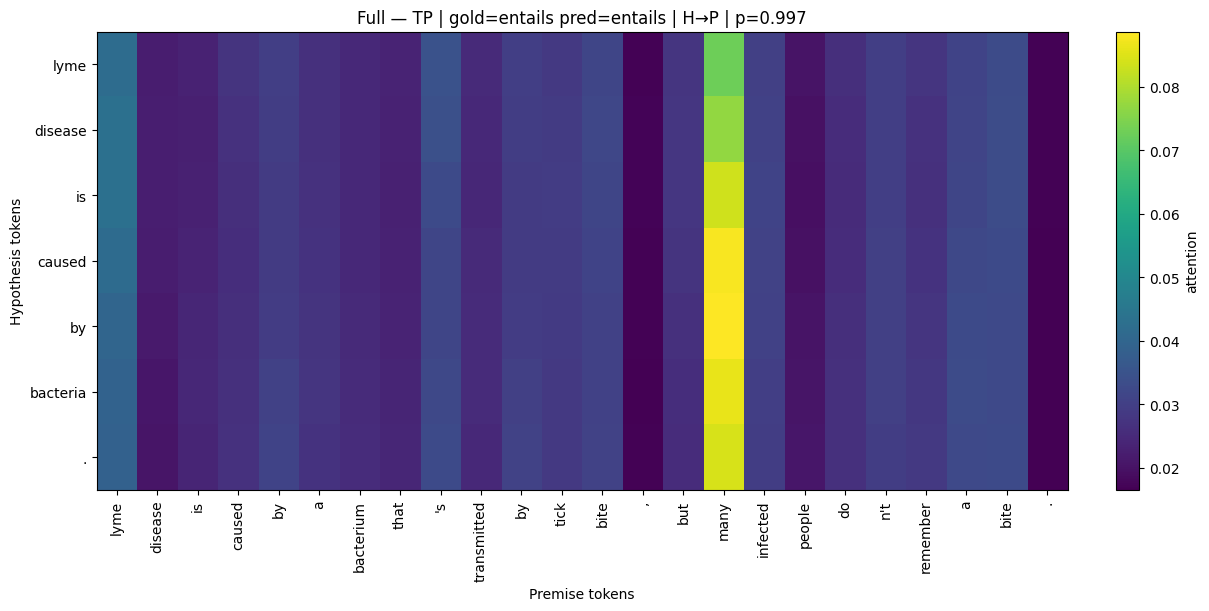

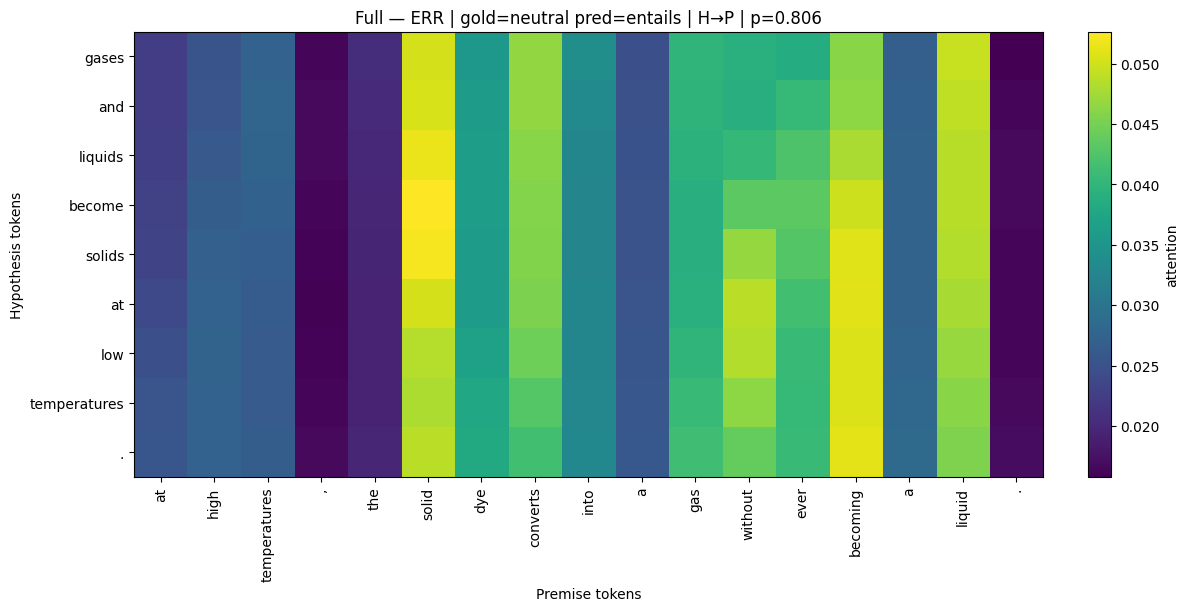

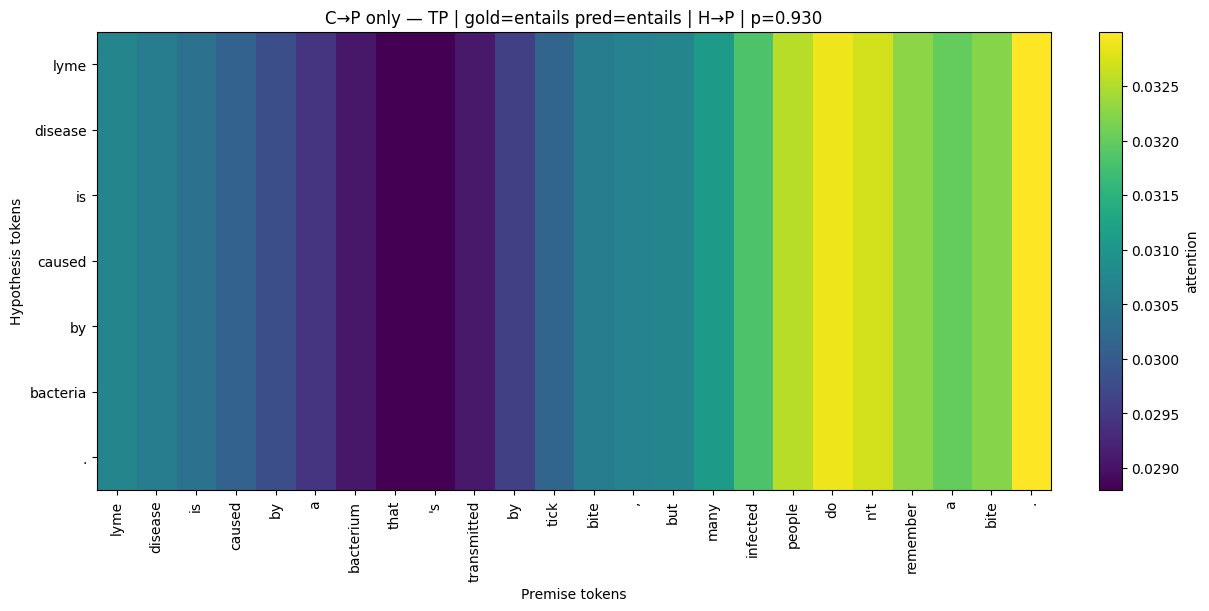

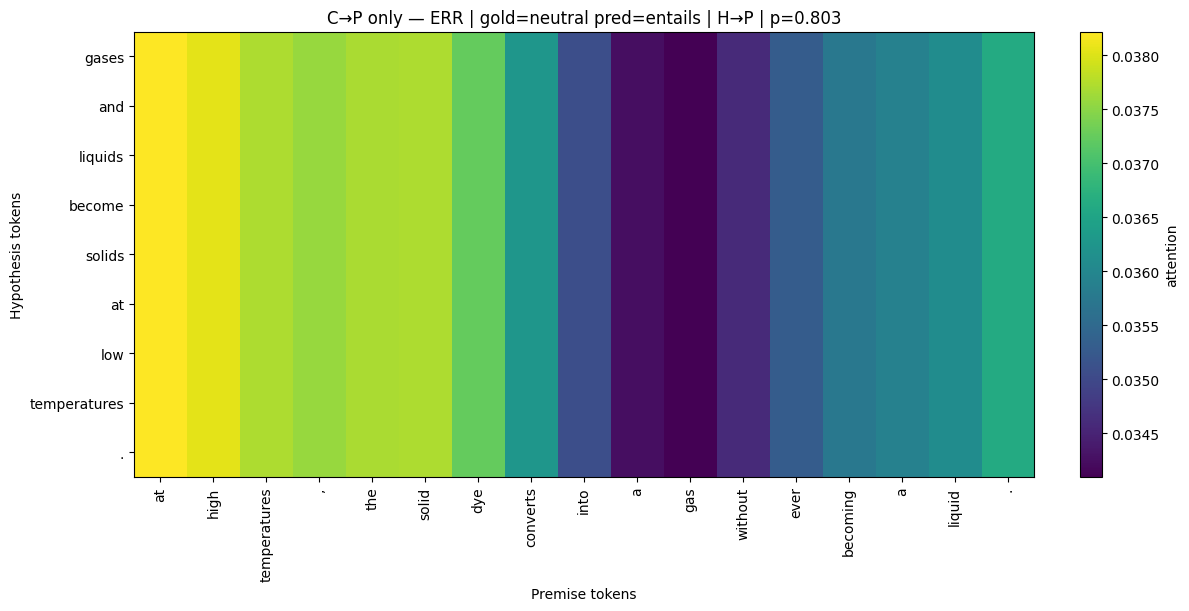

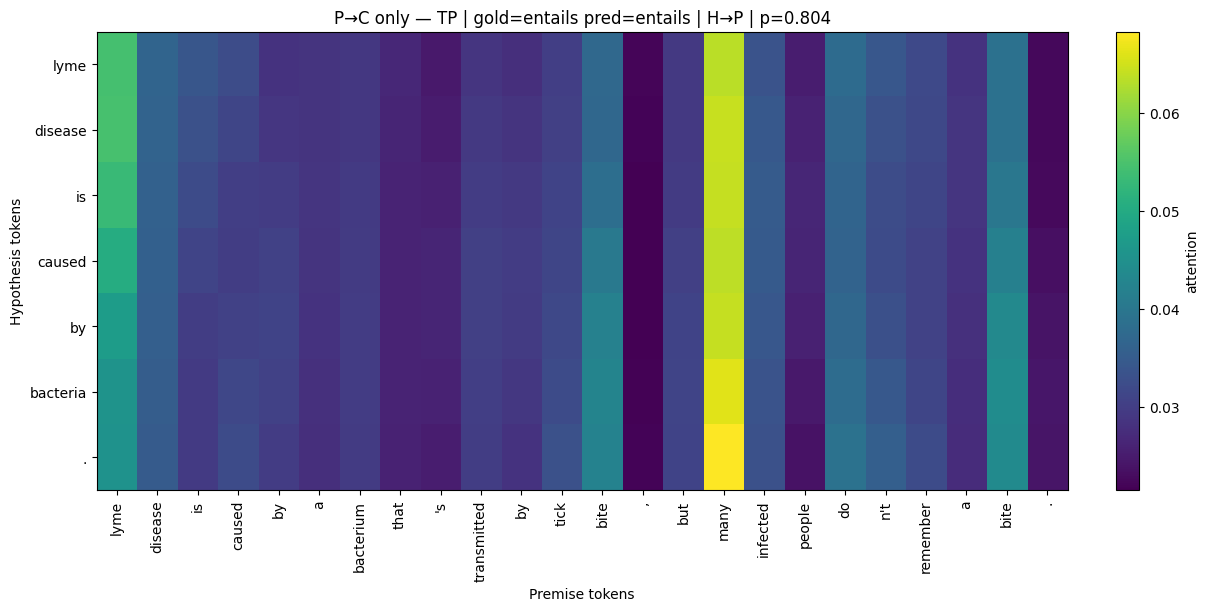

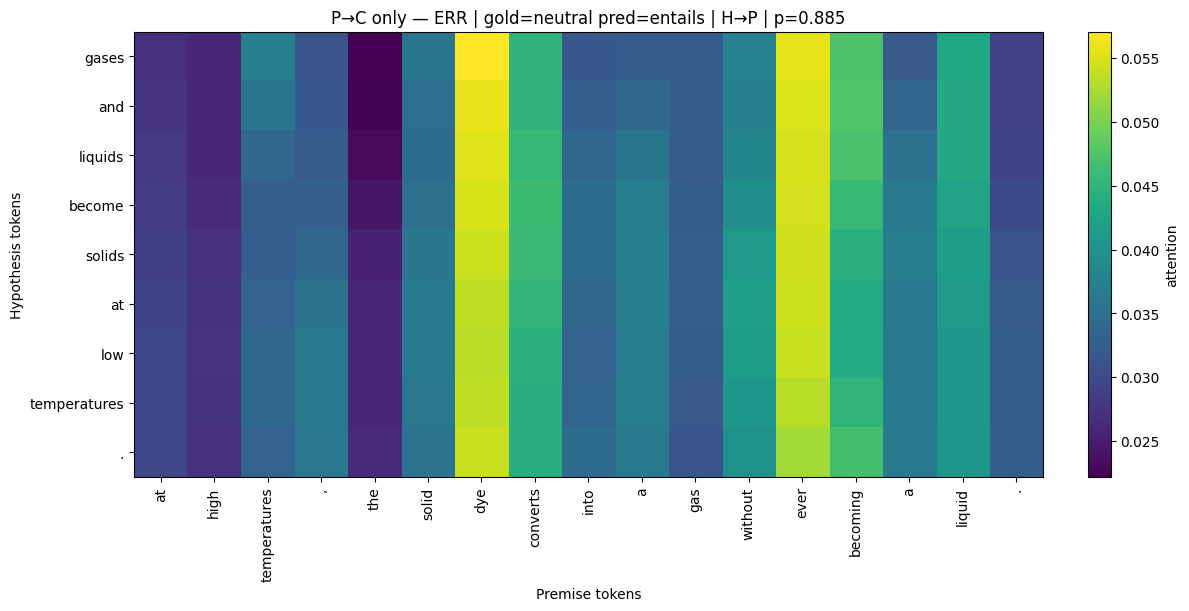

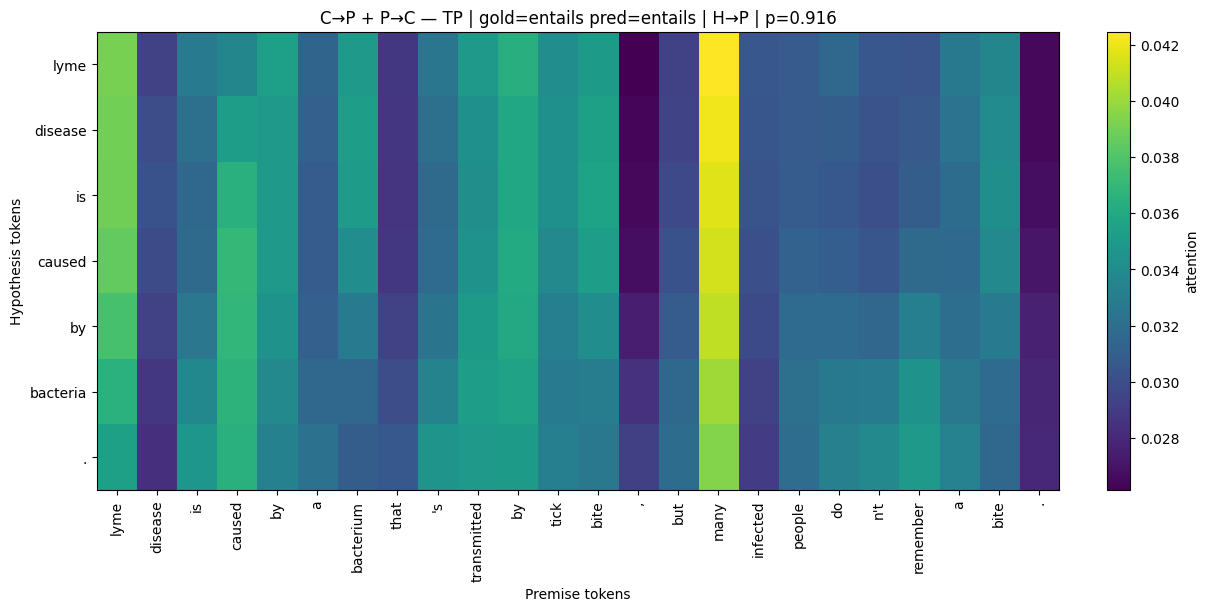

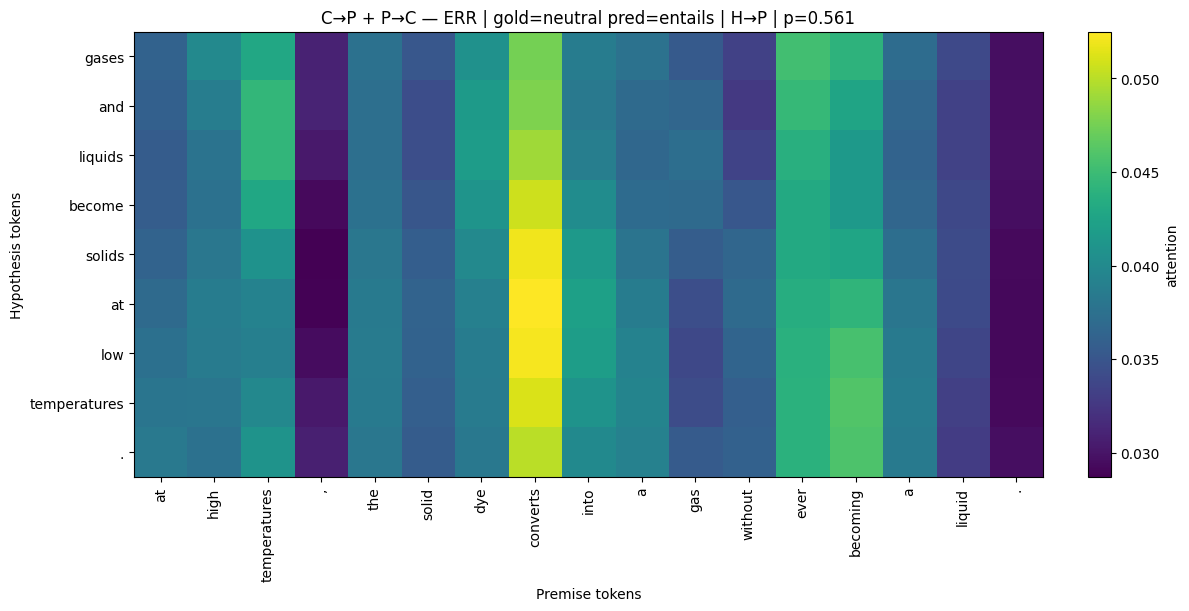

In [ ]:

import os
import re
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------- config ----------
MODES = ["full", "c2p_only", "p2c_only", "c2p_p2c"]  # pick which models to visualize
THR = 0.5                   # decision threshold for positive (class 1)
AVG_LAYERS = False          # True = avg over layers + heads
SHOW_FULL = False           # True = also display the full S×S heatmap


LABEL_MAP = {0: "neutral", 1: "entails"}

# Pretty names for models
NAME_MAP = {
    "full": "Full",
    "c2p_only": "C→P only",
    "p2c_only": "P→C only",
    "c2p_p2c": "C→P + P→C",
}

# Saving options
SAVE_IMAGES = True
OUT_DIR = "attn_plots"
os.makedirs(OUT_DIR, exist_ok=True)

# id -> token map
id2tok = {i: w for i, w in enumerate(vocab_trans)}

# ---------- helpers ----------
def _tokens_no_pad(ids_1):
    ids = ids_1.squeeze(0).tolist()
    if PAD_IDX_TRANS in ids:
        ids = ids[:ids.index(PAD_IDX_TRANS)]
    return [id2tok.get(i, str(i)) for i in ids]

def _safe_name(s: str) -> str:
    s = s.replace("→", "to")
    s = re.sub(r"\s+", "-", s)
    s = re.sub(r"[^A-Za-z0-9_.\-]", "", s)
    return s

def _maybe_save(fig, filename):
    if SAVE_IMAGES and filename:
        fig.savefig(os.path.join(OUT_DIR, filename), dpi=220, bbox_inches='tight')

def _plot_full(A, prem_ids, hyp_ids, title, filename=None):
    prem = _tokens_no_pad(prem_ids); hyp = _tokens_no_pad(hyp_ids)
    S = len(prem) + len(hyp); Lp = len(prem)
    A = A[:S, :S]
    fig, ax = plt.subplots(figsize=(min(12, 0.35*S+4), min(10, 0.35*S+3)), constrained_layout=True)
    im = ax.imshow(A, aspect='auto')
    cbar = fig.colorbar(im, ax=ax); cbar.set_label('attention')
    ax.set_xticks(np.arange(S)); ax.set_xticklabels(prem + hyp, rotation=90)
    ax.set_yticks(np.arange(S)); ax.set_yticklabels(prem + hyp)
    ax.axvline(Lp-0.5, color='w', ls='--', lw=1); ax.axhline(Lp-0.5, color='w', ls='--', lw=1)
    ax.set_title(title)
    _maybe_save(fig, filename)
    plt.show(); plt.close(fig)

def _plot_h2p(A, prem_ids, hyp_ids, title, filename=None):
    prem = _tokens_no_pad(prem_ids); hyp = _tokens_no_pad(hyp_ids)
    Lp, Lh = len(prem), len(hyp); S = Lp + Lh
    A = A[:S, :S]; H2P = A[Lp:, :Lp]  # rows=hyp, cols=prem
    fig, ax = plt.subplots(figsize=(min(12, 0.3*(Lp+Lh)+4), 6), constrained_layout=True)
    im = ax.imshow(H2P, aspect='auto')
    cbar = fig.colorbar(im, ax=ax); cbar.set_label('attention')
    ax.set_xticks(np.arange(Lp)); ax.set_xticklabels(prem, rotation=90)
    ax.set_yticks(np.arange(Lh)); ax.set_yticklabels(hyp)
    ax.set_xlabel("Premise tokens"); ax.set_ylabel("Hypothesis tokens")
    ax.set_title(title)
    _maybe_save(fig, filename)
    plt.show(); plt.close(fig)

# ---------- model I/O ----------
def load_model(mode: str):
    mdl = DANLIDecoderOnlyNLI_BCE(
        embedding_matrix=embedding_matrix_trans,
        pad_idx=PAD_IDX_TRANS,
        nhead=8,
        d_model=EMBED_DIM,
        num_layers=4,
        dim_ff=512,
        dropout=0.2,
        ablation_mode=mode
    ).to(device)
    ckpt = results_train[mode]["ckpt_path"]
    mdl.load_state_dict(torch.load(ckpt, map_location=device))
    mdl.eval()
    return mdl

@torch.no_grad()
def _attn_matrix_and_pred(mdl, prem, hyp, avg_layers=False):
    logits, attn_list = mdl(prem, hyp, return_attn=True)  # list[L] of (H,B,S,S)
    if avg_layers:
        A = torch.stack(attn_list, dim=0).mean(0).mean(0)[0]  # (S,S)
    else:
        A = attn_list[-1].mean(0)[0]                          # (S,S)
    p = torch.sigmoid(torch.atleast_1d(logits)).item()       # prob of class 1 ("entails")
    pred = int(p >= THR)
    return p, pred, A.cpu().numpy()

@torch.no_grad()
def _pick_tp_err(mdl, loader, thr):
    tp = err = None
    for prem, hyp, y in loader:
        prem, hyp, y = prem.to(device), hyp.to(device), y.float().to(device)
        probs = torch.sigmoid(torch.atleast_1d(mdl(prem, hyp)))
        preds = (probs >= thr).float()
        for i in range(y.size(0)):
            ex = {"prem": prem[i:i+1].clone(), "hyp": hyp[i:i+1].clone(),
                  "y": int(y[i]), "p": float(probs[i]), "pred": int(preds[i])}
            if ex["y"] == 1 and ex["pred"] == 1 and tp is None: tp = ex
            if ex["pred"] != ex["y"] and err is None: err = ex
            if tp and err: return tp, err
    return tp, err

# ---------- run ----------
baseline = load_model("full")
_tp, _err = _pick_tp_err(baseline, test_loader_trans, thr=THR)

if _tp and _err:
    for mode in MODES:
        mdl = load_model(mode)
        model_name = NAME_MAP.get(mode, mode)
        for tag, ex in [("TP", _tp), ("ERR", _err)]:
            p, pred, A = _attn_matrix_and_pred(mdl, ex["prem"], ex["hyp"], avg_layers=AVG_LAYERS)
            y_name    = LABEL_MAP.get(ex["y"], str(ex["y"]))
            pred_name = LABEL_MAP.get(pred, str(pred))

            # Titles
            title_h2p  = f"{model_name} — {tag} | gold={y_name} pred={pred_name} | H→P | p={p:.3f}"
            title_full = f"{model_name} — {tag} | gold={y_name} pred={pred_name} | p={p:.3f}"

            # Filenames
            base = f"{mode}_{tag}_y-{y_name}_pred-{pred_name}_p-{p:.3f}"
            safe = _safe_name(base)
            fname_h2p  = f"{safe}_H2P.png"
            fname_full = f"{safe}_FULL.png"

            # Display + save
            _plot_h2p(A, ex["prem"], ex["hyp"], title_h2p, filename=fname_h2p)
            if SHOW_FULL:
                _plot_full(A, ex["prem"], ex["hyp"], title_full, filename=fname_full)
